In [ ]:
import pandas as pd

#get cg74 related cgs in a list
file_path = "../inflammation_HANNUM_with_proper_selection/cd_74_associated_cpgs_2ndgeneration.txt"
with open(file_path, "r") as file:
    cd_74_associated_cpgs_list = [line.strip() for line in file]  # Removes any trailing newlines
cd_74_associated_cpgs_set=set(cd_74_associated_cpgs_list)
#read meta
train_meta = pd.read_csv('computage_train_meta.tsv', sep='\t', index_col=0).T
train_meta.columns = train_meta.columns.str.lower()
#delete duplicate cols
train_meta = train_meta.loc[:, ~train_meta.columns.duplicated(keep='first')]

In [ ]:
#dont run unnecessary, it takes a long time to read
train_betas_UNMODIFIABLE = pd.read_pickle('train_betas.pkl') #takes 15m to read
#drop duplicate cols
train_betas_UNMODIFIABLE = train_betas_UNMODIFIABLE.loc[:, ~train_betas_UNMODIFIABLE.columns.duplicated(keep='first')]
train_betas = train_betas_UNMODIFIABLE.copy()

In [6]:
#keep only rows which are in the infl_cg_set
train_betas = train_betas[train_betas.index.isin(cd_74_associated_cpgs_set)] #all the cg sites are present
# Drop columns with more than 250 missing values
train_betas = train_betas.loc[:, train_betas.isnull().sum() <= 250]
# Drop rows with more than 2500 missing values
train_betas = train_betas.loc[train_betas.isnull().sum(axis=1) <= 2500]
#fill nan values with means
train_betas.fillna(train_betas.mean(), inplace=True)
#the raw and meta has to be in the same column order
train_meta = train_meta[list(train_betas.columns)]

In [ ]:
import torch
from torch.utils.data import Dataset

#definte the dataset class
class MethylationDataset(Dataset):
    def __init__(self, meta_table, raw_table, transform=None):
        self.meta_table = meta_table
        self.raw_table = raw_table
        
    def __len__(self):
        return self.raw_table.shape[1]

    def __getitem__(self, idx):
        # Ensure the index is within the bounds of the meta_table
        if idx >= self.__len__():
            print('Index out of bounds:', idx)
            return -1

        # Extract the RNA data and age
        try:
            rna_data = self.raw_table.iloc[:, idx].tolist()
            age=float(self.meta_table.iloc[5,idx])
        except IndexError as e:
            print(f"IndexError: {e}, idx: {idx}")
            return -1
        return torch.tensor(rna_data), age
    
    def get_features_and_targets(self):
        features = []
        targets = []
        for idx in range(len(self)):
            rna_data, age = self[idx]
            features.append(rna_data.numpy())
            targets.append(age.numpy())
        return np.array(features), np.array(targets)
        

In [ ]:
#save the features order so later we can predict on other datasets
with open("inflamm_hugging_elnet_gen2_all_cg_order.txt", "w") as f:
    for item in list(train_betas.index):
        f.write(item + "\n")

In [ ]:
from sklearn.model_selection import train_test_split

#create the dataset object, and random train test split 80-20
transcriptomic_dataset = MethylationDataset(train_meta,train_betas)
train_data, test_data = train_test_split(transcriptomic_dataset, test_size=0.2, random_state=42)

print("Train data size:", len(train_data))
print("Test data size:", len(test_data))

Train data size: 5935
Test data size: 1484


In [ ]:
# Initialize lists for features and targets
X_train = []
y_train = []

for features, target in train_data:
    X_train.append(features)
    y_train.append(target)

X_test = []
y_test = []

for features, target in test_data:
    X_test.append(features)
    y_test.append(target)

In [ ]:
import warnings
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning, module="torch.storage")

# Define the pipeline
pipeline = make_pipeline(
    MinMaxScaler(),            
    ElasticNet(max_iter=10000)
)

# Define the parameter grid
param_grid = {
    'elasticnet__alpha': np.linspace(0.0001, 1, 20),    # 50 values between 0.001 and 1
    'elasticnet__l1_ratio': np.linspace(0.1, 0.9, 10)  # 30 values between 0.1 and 0.9
}


# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    #scoring='neg_mean_squared_error',
    scoring='neg_mean_absolute_error',
    n_jobs=2,
    verbose=1
)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation score:", -grid_search.best_score_)

# Extract the best model
best_model = grid_search.best_estimator_

# Print model coefficients and intercept
elasticnet = best_model.named_steps['elasticnet']
print("Coefficients:", elasticnet.coef_)
print("Intercept:", elasticnet.intercept_)
print("Number of iterations:", elasticnet.n_iter_)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


/home/speter/anaconda3/lib/python3.12/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))
/home/speter/anacond

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr
import joblib
# Make predictions on the test data

test_predictions = best_model.predict(X_test) #THIS IS FROM THE CV 

# Evaluate the model
mse = mean_squared_error(y_test, test_predictions)
print("TEST Mean Squared Error:", mse)
mae = mean_absolute_error(y_test, test_predictions)
print("Mean Absolute Error:", mae)

# Assuming y_true and y_pred are numpy arrays or lists of true and predicted values
pearson_r, _ = pearsonr(y_test, test_predictions)
print("Pearson correlation coefficient:", pearson_r)

joblib.dump(best_model, 'hugging_inflamm_elastic_3_2ndgeneration.pkl')

TEST Mean Squared Error: 633.8612586390777
Mean Absolute Error: 9.561165413764483
Pearson correlation coefficient: 0.5220400356480881


['hugging_inflamm_elastic_3_2ndgeneration.pkl']

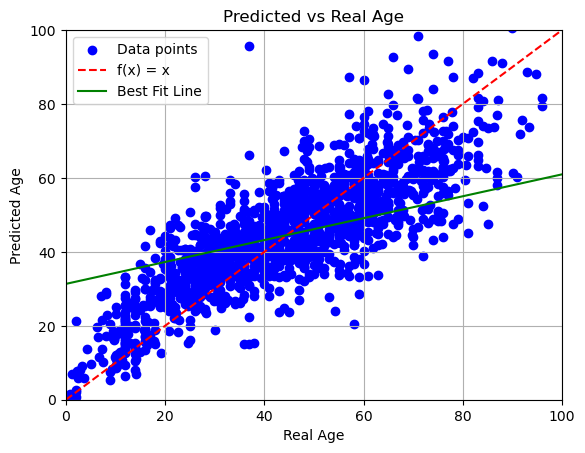

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create scatter plot
plt.scatter(y_test, test_predictions, color='blue', label='Data points')

# Add the f(x) = x line
x_line = np.linspace(0, 100, 400)
y_line = x_line
plt.plot(x_line, y_line, color='red', linestyle='--', label='f(x) = x')

# Calculate best fit line
fit = np.polyfit(y_test, test_predictions, 1)  # degree=1 for linear
best_fit_fn = np.poly1d(fit)
plt.plot(x_line, best_fit_fn(x_line), color='green', label='Best Fit Line')

# Labels and styling
plt.xlabel('Real Age')
plt.ylabel('Predicted Age')
plt.title('Predicted vs Real Age')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend()
plt.grid(True)
plt.show()
